# La Liga Market Value Analysis
## Notebook 02 · Exploratory Analysis and OLS Regression

**Dataset:** `laliga_cleaned.csv` — 2,679 outfield player-season observations,
La Liga 2014/15 – 2024/25




---
## 1. Introduction

### Research Question

> **Does on-pitch performance predict market value in La Liga?
> The role of expected goals, assists, and playing time (2014–2024)**

Transfer fees in football have gone up a lot over the last decade, but it's not completely obvious how much a player's statistics actually drive their price. Regular stats like goals and assists depend partly on luck — a striker can get ten shots and score zero, or score from their only chance of the game. Expected goals (xG) and expected assists (xA) try to fix this by measuring the *quality* of chances created and converted, not just the outcomes.

This notebook addresses two sub-questions:

1. **Which performance metrics best predict player market value in La Liga?**
   We test goals per 90, xG per 90, assists per 90, and xA per 90 as predictors of market value, with position, minutes played, age, and season as controls.

2. **Does xG predict market value better than raw goals — does the market reward underlying performance or just results?**
   We compare a model using traditional stats (goals, assists) against one using xG/xA, to see which one explains market value better.

### Data sources

| Source | What it contains |
|--------|------------------|
| Understat (scraped) | Goals, assists, xG, xA, minutes per player per season |
| Transfermarkt (Kaggle) | Market value snapshots per player per season |

**Filters applied:** outfield players only (no goalkeepers); at least 450 minutes played; market value of at least €500,000. This leaves **2,679 player-season records**.


### Connection to Project 1

In the first project, shots on target was used as a proxy for expected goals (xG)
because xG data was not available in that dataset. This project uses xG directly,
which makes it possible to actually test whether the transfer market rewards
underlying performance quality or just results. It also means we can compare how
much better xG is as a predictor compared to a simple shot count — something
that wasn't possible before.


---
## 2. Exploratory Data Analysis


In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración global de figuras
plt.rcParams.update({
    'figure.dpi':       100,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})

# Carpeta de figuras
import os
carpeta_figuras = "figures"
os.makedirs(carpeta_figuras, exist_ok=True)

# guarda la figura en la carpeta de salida
def save(name):
    plt.savefig(f"{carpeta_figuras}/{name}", dpi=150, bbox_inches='tight')
    print(f"Saved: {carpeta_figuras}/{name}")

# Colores por posición
colores_pos = {'Defender': '#2E7EBF', 'Midfielder': '#27AE60', 'Forward': '#E07B39'}
orden_pos  = ['Defender', 'Midfielder', 'Forward']

# Cargar dataset limpio
df = pd.read_csv("laliga_cleaned.csv")
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Temporadas: {df['season_year'].min()} – {df['season_year'].max()}")
print(f"Posiciones: {dict(df['position_simple'].value_counts())}")

df.head()

Dataset cargado: 2,679 filas × 31 columnas
Temporadas: 2014 – 2024
Posiciones: {'Defender': np.int64(1163), 'Forward': np.int64(812), 'Midfielder': np.int64(704)}


,player_id,player_name,season,season_year,team_title,games,time,goals,assists,shots,...,position,position_simple,pos_Forward,pos_Midfielder,age,age_squared,market_value_in_eur,log_market_value,match_type,fuzzy_score
0,2270,Antoine Griezmann,2014/15,2014,Atletico Madrid,37,2490,22,1,78,...,F M S,Forward,1,0,23.0,529.0,45000000.0,17.622173,exact,100.0
1,1125,Carlos Bacca,2014/15,2014,Sevilla,37,2581,20,6,69,...,F S,Forward,1,0,28.0,784.0,25000000.0,17.034386,exact,100.0
2,2098,Luis Suárez,2014/15,2014,Barcelona,27,2182,16,14,75,...,F S,Forward,1,0,27.0,729.0,80000000.0,18.197537,exact,100.0
3,2370,Karim Benzema,2014/15,2014,Real Madrid,29,2325,15,10,69,...,F,Forward,1,0,27.0,729.0,50000000.0,17.727534,exact,100.0
4,4060,Sergio García,2014/15,2014,Espanyol,35,3030,14,9,80,...,F M S,Forward,1,0,31.0,961.0,6000000.0,15.607270,exact,100.0


### Figure 1 — Log market value distribution by position

These violin plots show how log market value is spread across positions. Forwards tend to have higher valuations on average, which makes sense given how much the market seems to value goal-scoring.


Saved: figures/fig_01_log_mv_by_position.png


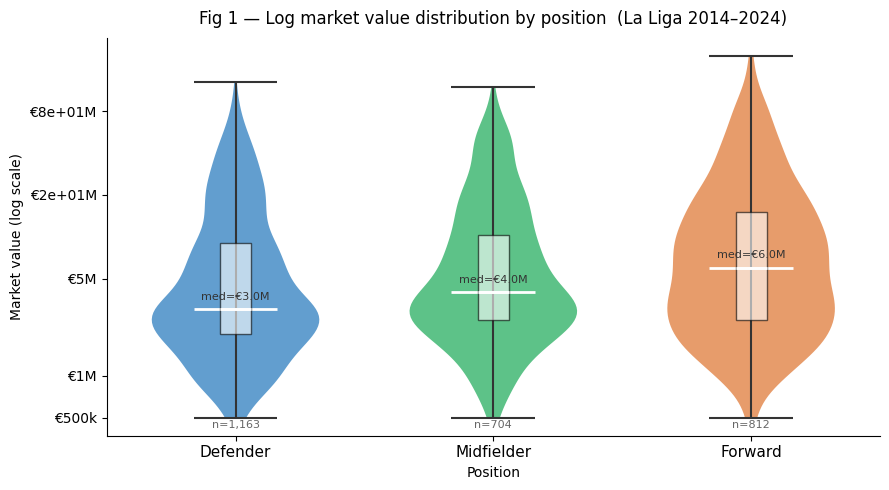

In [2]:
# fig 1: distribución de log_market_value por posición
fig, ax = plt.subplots(figsize=(9, 5))

# Datos por posición en el orden correcto
data_by_pos = [df.loc[df['position_simple'] == p, 'log_market_value'].values
               for p in orden_pos]

# Violín
vp = ax.violinplot(data_by_pos, positions=[1, 2, 3],
                   showmedians=True, showextrema=True, widths=0.65)

# Colorear cada violín
for i, (body, color) in enumerate(zip(vp['bodies'], colores_pos.values())):
    body.set_facecolor(color)
    body.set_alpha(0.75)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)
for part in ['cmins', 'cmaxes', 'cbars']:
    vp['cmedians' if part == 'cmedians' else part].set_color('#333333')

# Overlay boxplot para IQR claro
bp = ax.boxplot(data_by_pos, positions=[1, 2, 3],
                widths=0.12, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                boxprops=dict(facecolor='white', alpha=0.6),
                whiskerprops=dict(visible=False),
                capprops=dict(visible=False),
                flierprops=dict(visible=False))

# Eje Y con etiquetas en €
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(orden_pos, fontsize=11)
euro_ticks = [500_000, 1_000_000, 5_000_000, 20_000_000, 80_000_000]
ax.set_yticks([np.log(v) for v in euro_ticks])
ax.set_yticklabels([f"€{v/1e6:.1g}M" if v >= 1e6 else f"€{v/1e3:.0f}k"
                    for v in euro_ticks])
ax.set_ylabel("Market value (log scale)")
ax.set_xlabel("Position")
ax.set_title("Fig 1 — Log market value distribution by position  (La Liga 2014–2024)", pad=10)

# Anotaciones: mediana y N
for i, (pos, xpos) in enumerate(zip(orden_pos, [1, 2, 3])):
    sub = df[df['position_simple'] == pos]
    med = sub['log_market_value'].median()
    ax.text(xpos, med + 0.12, f"med=€{np.exp(med)/1e6:.1f}M",
            ha='center', va='bottom', fontsize=8, color='#333')
    ax.text(xpos, ax.get_ylim()[0] + 0.1, f"n={len(sub):,}",
            ha='center', va='bottom', fontsize=8, color='#666')

plt.tight_layout()
save("fig_01_log_mv_by_position.png")
plt.show()


**What this shows:** Forwards have the highest typical market values, followed by Midfielders and Defenders. But even on the log scale, the distributions overlap a lot — so position alone doesn't explain market value. There are very expensive Defenders and relatively cheap Forwards. A small number of elite players in each position are worth far more than the rest.


### Figure 2 — xG per 90 vs log market value, by position

This scatter plot shows how xG per 90 relates to market value for each position, with a regression line to show the general trend.


Saved: figures/fig_02_xg_per90_vs_log_mv.png


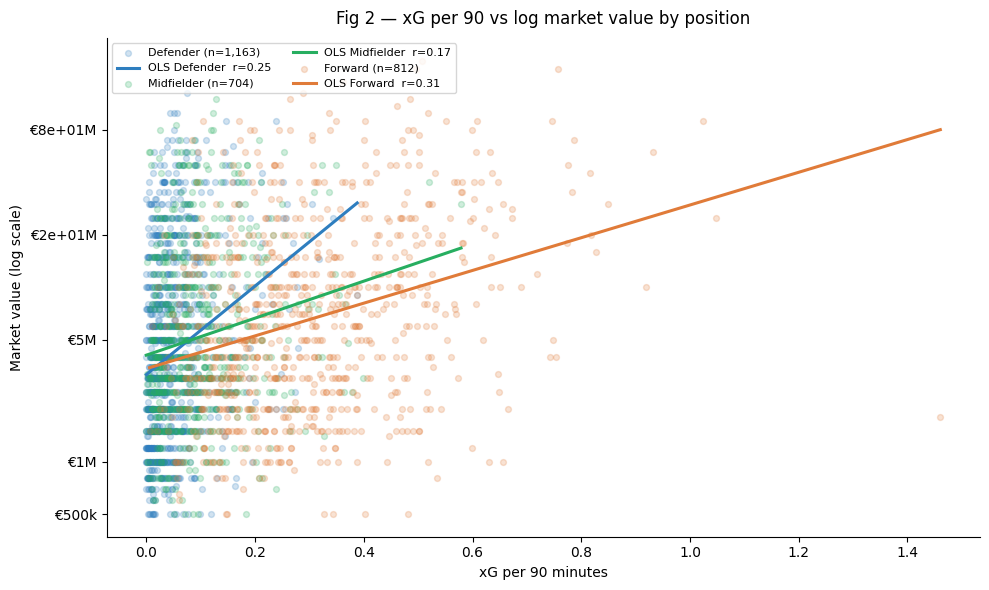

In [3]:
# fig 2: xg_per90 vs log_market_value — scatter + ols por posición
fig, ax = plt.subplots(figsize=(10, 6))

for pos, color in colores_pos.items():
    sub = df[df['position_simple'] == pos]

    # Puntos con transparencia para densidad
    ax.scatter(sub['xG_per90'], sub['log_market_value'],
               alpha=0.22, s=18, color=color, label=f"{pos} (n={len(sub):,})")

    # Línea de regresión OLS
    slope, intercept, r, p, se = stats.linregress(sub['xG_per90'], sub['log_market_value'])
    x_line = np.linspace(sub['xG_per90'].min(), sub['xG_per90'].max(), 200)
    ax.plot(x_line, intercept + slope * x_line, color=color, linewidth=2.2,
            label=f"OLS {pos}  r={r:.2f}")

# Eje Y en €
euro_ticks = [500_000, 1_000_000, 5_000_000, 20_000_000, 80_000_000]
ax.set_yticks([np.log(v) for v in euro_ticks])
ax.set_yticklabels([f"€{v/1e6:.1g}M" if v >= 1e6 else f"€{v/1e3:.0f}k"
                    for v in euro_ticks])
ax.set_xlabel("xG per 90 minutes")
ax.set_ylabel("Market value (log scale)")
ax.set_title("Fig 2 — xG per 90 vs log market value by position", pad=10)
ax.legend(fontsize=8, ncol=2, loc='upper left')

plt.tight_layout()
save("fig_02_xg_per90_vs_log_mv.png")
plt.show()


**What this shows:** There is a clear positive trend between xG per 90 and market value for Forwards and Midfielders. The relationship is weaker for Defenders, which makes sense because xG mainly reflects attacking play. The wide scatter at any given xG level shows that xG alone isn't enough to explain market value — position, age, and club matter a lot too.


### Figure 3 — Goals per 90 vs xG per 90

This plot examines how closely actual goals track expected goals.
Players above the diagonal are over-performing their xG (finishing above expectation);
players below are under-performing.


Saved: figures/fig_03_goals_vs_xg_per90.png


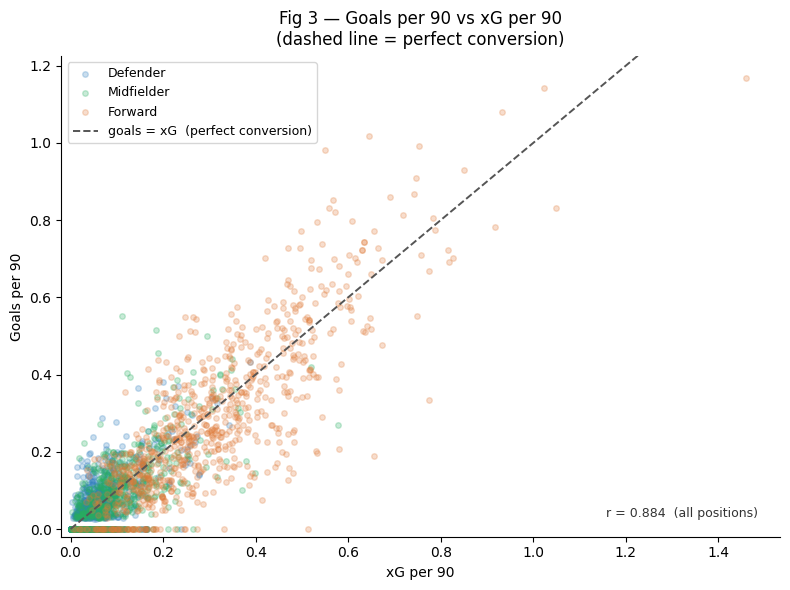

Global Pearson r (goals_per90 vs xG_per90): 0.8836  p=0.00e+00


In [4]:
# fig 3: goals_per90 vs xg_per90 — fidelidad xg
fig, ax = plt.subplots(figsize=(8, 6))

for pos, color in colores_pos.items():
    sub = df[df['position_simple'] == pos]
    ax.scatter(sub['xG_per90'], sub['goals_per90'],
               alpha=0.25, s=16, color=color, label=pos)

# Línea diagonal perfecta (goals = xG)
lim_max = max(df['xG_per90'].max(), df['goals_per90'].max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], color='#555', linewidth=1.4,
        linestyle='--', label='goals = xG  (perfect conversion)')

# Correlación global
r_global, p_global = stats.pearsonr(df['xG_per90'], df['goals_per90'])
ax.text(0.97, 0.04, f"r = {r_global:.3f}  (all positions)",
        transform=ax.transAxes, ha='right', fontsize=9, color='#333')

ax.set_xlabel("xG per 90")
ax.set_ylabel("Goals per 90")
ax.set_title("Fig 3 — Goals per 90 vs xG per 90\n(dashed line = perfect conversion)", pad=8)
ax.legend(fontsize=9)
ax.set_xlim(-0.02, lim_max)
ax.set_ylim(-0.02, df['goals_per90'].max() * 1.05)

plt.tight_layout()
save("fig_03_goals_vs_xg_per90.png")
plt.show()

print(f"Global Pearson r (goals_per90 vs xG_per90): {r_global:.4f}  p={p_global:.2e}")


**What this shows:** Goals and xG per 90 are very closely related (r ≈ 0.88). Players near the diagonal are converting chances at the expected rate. Forwards show more scatter — some are clinical finishers who score more than their xG would predict, while others underperform. Because goals and xG are so correlated, running models with each one separately (before combining them) is a good idea to avoid confusion between the two.


### Figure 4 — Average market value by season (2014–2024)

Time-trend in market valuations reveals structural inflation in La Liga player values.


Saved: figures/fig_04_avg_mv_by_season.png


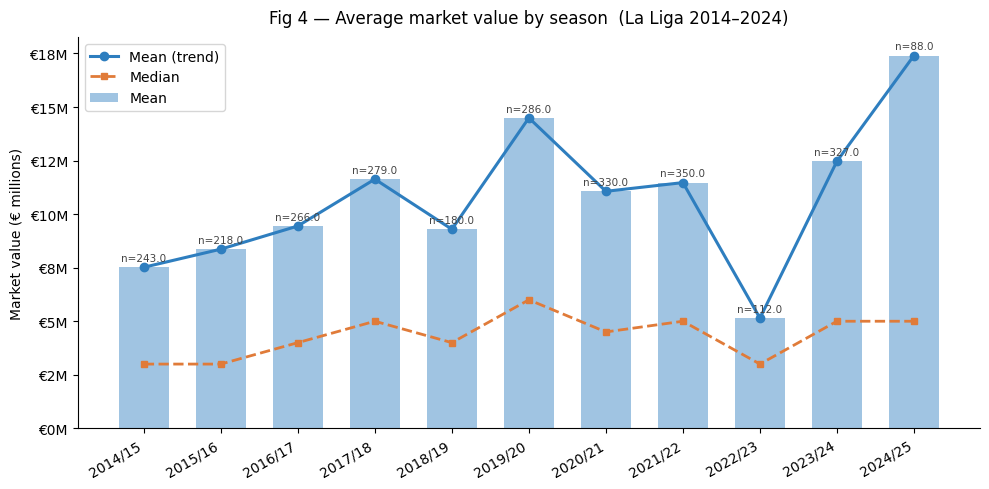

In [5]:
# fig 4: valor de mercado promedio por temporada
season_avg = (df.groupby('season_year')
               .agg(mean_mv=('market_value_in_eur', 'mean'),
                    median_mv=('market_value_in_eur', 'median'),
                    n=('market_value_in_eur', 'count'))
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))

# Barras de la media con sombreado semitransparente
ax.bar(season_avg['season_year'], season_avg['mean_mv'] / 1e6,
       color='#2E7EBF', alpha=0.45, width=0.65, label='Mean')
ax.plot(season_avg['season_year'], season_avg['mean_mv'] / 1e6,
        color='#2E7EBF', linewidth=2.2, marker='o', markersize=6, label='Mean (trend)')

# Línea de la mediana
ax.plot(season_avg['season_year'], season_avg['median_mv'] / 1e6,
        color='#E07B39', linewidth=2, linestyle='--', marker='s', markersize=5,
        label='Median')

# Anotación de N por temporada
for _, row in season_avg.iterrows():
    ax.text(row['season_year'], row['mean_mv'] / 1e6 + 0.2,
            f"n={row['n']}", ha='center', va='bottom', fontsize=7.5, color='#444')

ax.set_xticks(season_avg['season_year'])
ax.set_xticklabels([f"{y}/{str(y+1)[-2:]}" for y in season_avg['season_year']],
                   rotation=30, ha='right')
ax.set_ylabel("Market value (€ millions)")
ax.set_title("Fig 4 — Average market value by season  (La Liga 2014–2024)", pad=10)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.0f}M"))

plt.tight_layout()
save("fig_04_avg_mv_by_season.png")
plt.show()


**What this shows:** Average market values in La Liga roughly doubled between 2014/15 and 2021/22, which fits with the general inflation in football transfers. The median is lower and rises more slowly because it isn't pulled up by superstar valuations the same way the mean is. The 2022/23 and 2024/25 seasons have fewer records because Transfermarkt valuations sometimes lag behind current seasons. This trend is why we include `season_year` as a control in all regressions.


### Figure 5 — Top 20 most valuable player-season observations


Saved: figures/fig_05_top20_most_valuable.png


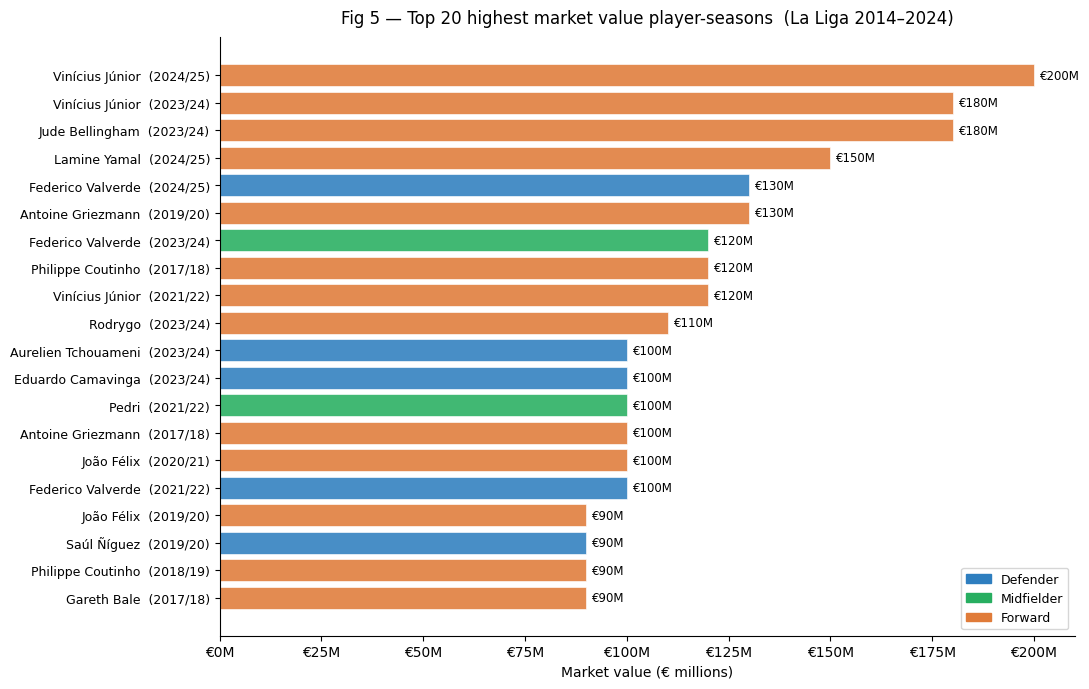

                         label position_simple  market_value_in_eur
    Vinícius Júnior  (2024/25)         Forward          200000000.0
    Vinícius Júnior  (2023/24)         Forward          180000000.0
    Jude Bellingham  (2023/24)         Forward          180000000.0
       Lamine Yamal  (2024/25)         Forward          150000000.0
  Federico Valverde  (2024/25)        Defender          130000000.0
  Antoine Griezmann  (2019/20)         Forward          130000000.0
  Federico Valverde  (2023/24)      Midfielder          120000000.0
  Philippe Coutinho  (2017/18)         Forward          120000000.0
    Vinícius Júnior  (2021/22)         Forward          120000000.0
            Rodrygo  (2023/24)         Forward          110000000.0
Aurelien Tchouameni  (2023/24)        Defender          100000000.0
  Eduardo Camavinga  (2023/24)        Defender          100000000.0
              Pedri  (2021/22)      Midfielder          100000000.0
  Antoine Griezmann  (2017/18)         Forward  

In [6]:
# fig 5: top 20 player-seasons por valor de mercado
top20 = (df[['player_name', 'season', 'position_simple', 'team_title',
             'market_value_in_eur']]
         .sort_values('market_value_in_eur', ascending=False)
         .head(20)
         .reset_index(drop=True))

top20['label'] = top20['player_name'] + "  (" + top20['season'] + ")"
top20['color'] = top20['position_simple'].map(colores_pos)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(range(len(top20)), top20['market_value_in_eur'] / 1e6,
               color=top20['color'], edgecolor='white', linewidth=0.5, alpha=0.88)

# Etiquetas de valor
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['market_value_in_eur'] / 1e6 + 1.5, i,
            f"€{row['market_value_in_eur']/1e6:.0f}M",
            va='center', fontsize=8.5)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['label'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Market value (€ millions)")
ax.set_title("Fig 5 — Top 20 highest market value player-seasons  (La Liga 2014–2024)", pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.0f}M"))

# Leyenda de posición
legend_patches = [mpatches.Patch(color=c, label=p) for p, c in colores_pos.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
save("fig_05_top20_most_valuable.png")
plt.show()

print(top20[['label','position_simple','market_value_in_eur']].to_string(index=False))


**What this shows:** The most expensive player-seasons are mostly Forwards, with a few creative Midfielders like Pedri and Bellingham making the list. The same players appear in multiple seasons, showing that elite valuations tend to persist. These superstar values are why we use a log transformation — without it, a handful of €100M+ valuations would dominate the regression.


Looking at the scatter plots, xG and goals both seem to correlate with market value in a similar way. I am not sure yet which one will be a stronger predictor in the regression — that is exactly what the four models are designed to test.

---
## 3. OLS Regression — Predicting Log Market Value

### Model specification

I built three OLS models with `log_market_value` as the dependent variable.
All models include minutes played (`time`), position dummies (`pos_Forward`, `pos_Midfielder`
with Defender as the reference), and `season_year` to absorb market inflation.

| Model | Key predictors | Purpose |
|-------|---------------|---------|
| **Model 1** | `goals_per90`, `assists_per90` | Traditional (box-score) metrics |
| **Model 2** | `xG_per90`, `xA_per90` | Modern (expected) metrics |
| **Model 3** | Both sets combined | Joint specification |

We use standard OLS throughout (homoskedastic standard errors).


In [7]:
# Importar statsmodels para regresión OLS
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Variables de control comunes a todos los modelos
formula_controles = "time + pos_Forward + pos_Midfielder + season_year"

# especificaciones de los tres modelos
formulas = {
    "Model 1 (Traditional)": f"log_market_value ~ goals_per90 + assists_per90 + {formula_controles}",
    "Model 2 (xG/xA)":       f"log_market_value ~ xG_per90 + xA_per90 + {formula_controles}",
    "Model 3 (Combined)":    (f"log_market_value ~ goals_per90 + xG_per90 + "
                               f"assists_per90 + xA_per90 + {formula_controles}"),
}

# ajustar cada modelo con OLS
resultados_base = {}
for name, formula in formulas.items():
    resultado = smf.ols(formula, data=df).fit()
    resultados_base[name] = resultado
    print(f"{name}:  R²={resultado.rsquared:.4f}  adj-R²={resultado.rsquared_adj:.4f}  "
          f"N={int(resultado.nobs):,}  AIC={resultado.aic:.1f}")
results = resultados_base


Model 1 (Traditional):  R²=0.2683  adj-R²=0.2666  N=2,679  AIC=7699.4
Model 2 (xG/xA):  R²=0.2662  adj-R²=0.2645  N=2,679  AIC=7707.0
Model 3 (Combined):  R²=0.2778  adj-R²=0.2756  N=2,679  AIC=7668.2


### Model 1 — Traditional metrics (goals, assists)


In [8]:
print(results["Model 1 (Traditional)"].summary())


                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     163.3
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          3.95e-177
Time:                        22:56:50   Log-Likelihood:                -3842.7
No. Observations:                2679   AIC:                             7699.
Df Residuals:                    2672   BIC:                             7741.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -84.3057     13.479     -6.

### Model 2 — Modern metrics (xG, xA)


In [9]:
print(results["Model 2 (xG/xA)"].summary())


                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     161.5
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.68e-175
Time:                        22:56:50   Log-Likelihood:                -3846.5
No. Observations:                2679   AIC:                             7707.
Df Residuals:                    2672   BIC:                             7748.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -66.8674     13.498     -4.

### Model 3 — Combined model


In [10]:
print(results["Model 3 (Combined)"].summary())


                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     128.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.75e-182
Time:                        22:56:50   Log-Likelihood:                -3825.1
No. Observations:                2679   AIC:                             7668.
Df Residuals:                    2670   BIC:                             7721.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -76.3416     13.477     -5.

### Figure 6 — Coefficient comparison: Model 1 vs Model 2

These plots help compare the coefficients more clearly across the two models — at least visually.


Saved: figures/fig_06_coefficient_plot_m1_vs_m2.png


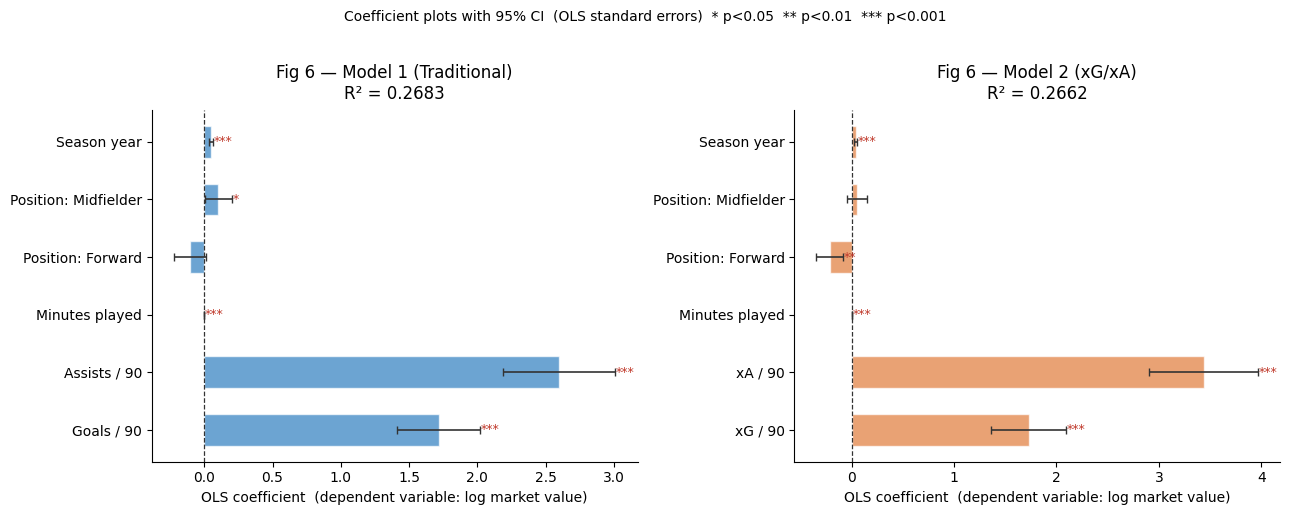

In [11]:
# fig 6: coeficientes model 1 vs model 2
# Extraer coeficientes e IC del 95% para variables de interés
perf_vars_m1 = ['goals_per90', 'assists_per90', 'time', 'pos_Forward', 'pos_Midfielder', 'season_year']
perf_vars_m2 = ['xG_per90',    'xA_per90',      'time', 'pos_Forward', 'pos_Midfielder', 'season_year']

# Etiquetas legibles
etiquetas = {
    'goals_per90':    'Goals / 90',
    'assists_per90':  'Assists / 90',
    'xG_per90':       'xG / 90',
    'xA_per90':       'xA / 90',
    'time':           'Minutes played',
    'pos_Forward':    'Position: Forward',
    'pos_Midfielder': 'Position: Midfielder',
    'season_year':    'Season year',
}

def extract_coef(result, vars_list):
    coef  = result.params[vars_list]
    ci    = result.conf_int().loc[vars_list]
    pvals = result.pvalues[vars_list]
    return coef, ci, pvals

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, (mname, vars_list), color in zip(
        axes,
        [("Model 1 (Traditional)", perf_vars_m1),
         ("Model 2 (xG/xA)",       perf_vars_m2)],
        ['#2E7EBF', '#E07B39']):

    coef, ci, pvals = extract_coef(results[mname], vars_list)
    labels = [etiquetas[v] for v in vars_list]
    y_pos  = range(len(vars_list))

    # Barras de error
    ax.barh(y_pos, coef.values, color=color, alpha=0.7,
            xerr=np.array([coef.values - ci.iloc[:, 0].values,
                           ci.iloc[:, 1].values - coef.values]),
            error_kw=dict(ecolor='#333', capsize=3, linewidth=1.2),
            edgecolor='white', height=0.55)

    # Línea en cero
    ax.axvline(0, color='#333', linewidth=0.9, linestyle='--')

    # Marcadores de significancia
    for i, (v, p) in enumerate(zip(vars_list, pvals.values)):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if stars:
            ax.text(coef[v] + (ci.iloc[i, 1] - coef[v]) + 0.005,
                    i, stars, va='center', fontsize=9, color='#C0392B')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels)
    ax.set_xlabel("OLS coefficient  (dependent variable: log market value)")
    ax.set_title(f"Fig 6 — {mname}\nR² = {results[mname].rsquared:.4f}", pad=8)

plt.suptitle("Coefficient plots with 95% CI  (OLS standard errors)  * p<0.05  ** p<0.01  *** p<0.001",
             fontsize=10, y=1.02)
plt.tight_layout()
save("fig_06_coefficient_plot_m1_vs_m2.png")
plt.show()


### Figure 7 — R² comparison across all three models


Saved: figures/fig_07_r2_comparison_base.png


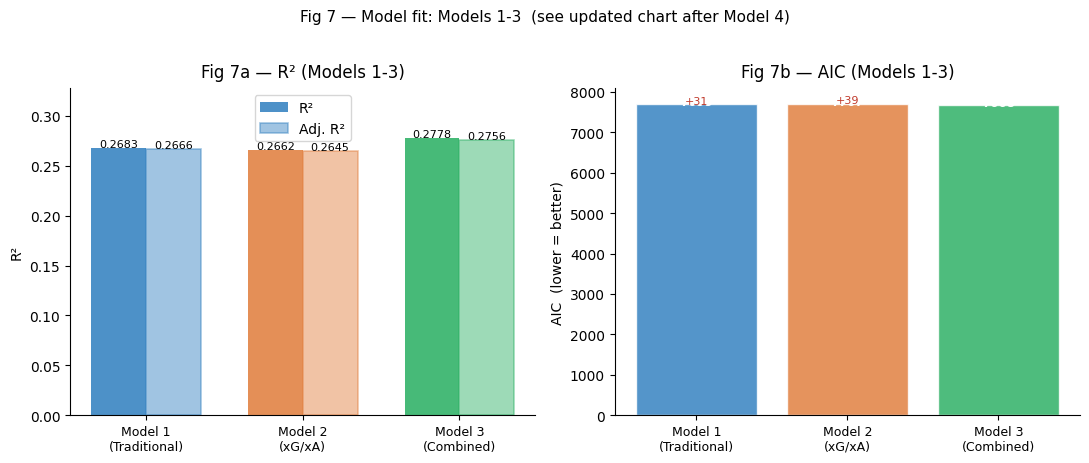

In [12]:
# fig 7: comparación de r² de los tres modelos base
# (Model 4 se mostrará en la sección siguiente tras añadir la edad)
model_names_base = [k for k in results.keys() if 'Age' not in k]
r2_base      = [results[k].rsquared     for k in model_names_base]
adj_r2_base  = [results[k].rsquared_adj for k in model_names_base]
aic_base     = [results[k].aic          for k in model_names_base]

short_names = ['Model 1\n(Traditional)', 'Model 2\n(xG/xA)', 'Model 3\n(Combined)']
colors      = ['#2E7EBF', '#E07B39', '#27AE60']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(3)
w = 0.35
axes[0].bar(x - w/2, r2_base,     width=w, color=colors, alpha=0.85, label='R²')
axes[0].bar(x + w/2, adj_r2_base, width=w, color=colors, alpha=0.45, label='Adj. R²',
            edgecolor=colors, linewidth=1.2)
for i, (r2, ar2) in enumerate(zip(r2_base, adj_r2_base)):
    axes[0].text(i - w/2, r2 + 0.001, f"{r2:.4f}", ha='center', fontsize=8)
    axes[0].text(i + w/2, ar2 + 0.001, f"{ar2:.4f}", ha='center', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, fontsize=9)
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, max(r2_base) * 1.18)
axes[0].set_title("Fig 7a — R² (Models 1-3)", pad=8)
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(x, aic_base, color=colors, alpha=0.82, edgecolor='white')
for i, a in enumerate(aic_base):
    axes[1].text(i, a - 30, f"{a:.0f}", ha='center', fontsize=8.5, color='white', fontweight='bold')
delta_aic = [a - min(aic_base) for a in aic_base]
for i, d in enumerate(delta_aic):
    if d > 0:
        axes[1].text(i, aic_base[i] + 10, f"+{d:.0f}", ha='center', fontsize=8, color='#C0392B')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, fontsize=9)
axes[1].set_ylabel("AIC  (lower = better)")
axes[1].set_title("Fig 7b — AIC (Models 1-3)", pad=8)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle("Fig 7 — Model fit: Models 1-3  (see updated chart after Model 4)", fontsize=11, y=1.02)
plt.tight_layout()
save("fig_07_r2_comparison_base.png")
plt.show()


### Figure 8 — Regression diagnostics for the best-fitting model

OLS assumptions are assessed via residual plots and a Q-Q plot.
We use the model with the highest adjusted R² (typically Model 3).


Saved: figures/fig_08_regression_diagnostics.png


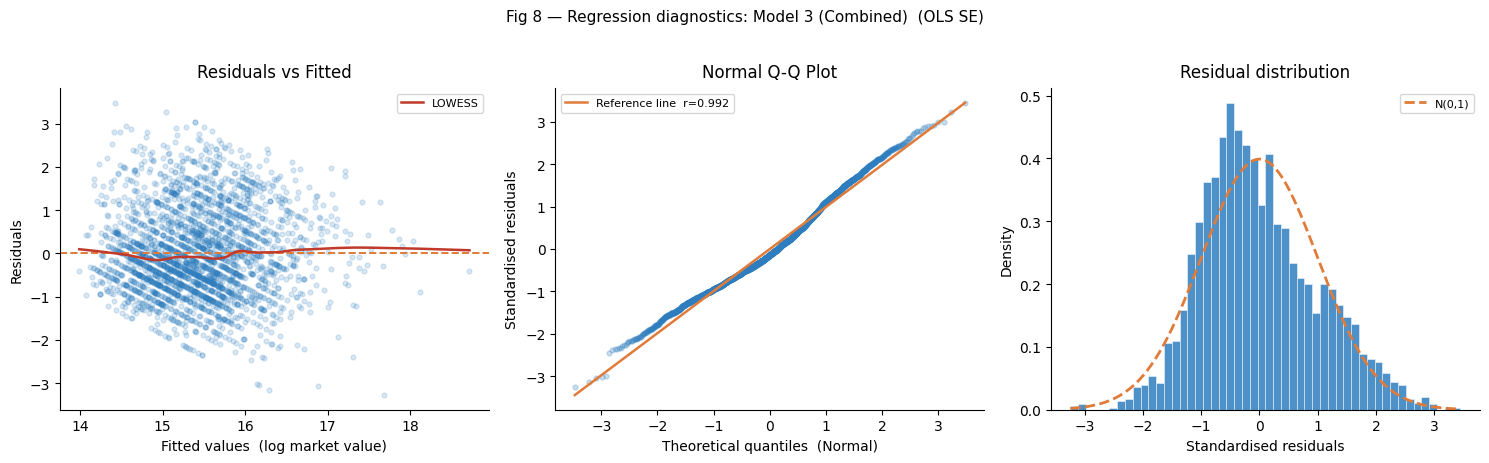

Jarque-Bera test: statistic=70.58  p=0.0000  skewness=0.396  excess kurtosis=2.935
Note: Standard OLS SEs assume homoskedastic residuals.


In [13]:
# fig 8: diagnósticos del mejor modelo
# Seleccionar el modelo con mayor R² ajustado
best_name   = max(results, key=lambda k: results[k].rsquared_adj)
best_result = results[best_name]

fitted     = best_result.fittedvalues
residuals  = best_result.resid
std_resid  = residuals / residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Residuales vs valores ajustados
axes[0].scatter(fitted, residuals, alpha=0.18, s=12, color='#2E7EBF')
axes[0].axhline(0, color='#E07B39', linewidth=1.4, linestyle='--')
# Línea suavizada (LOWESS)
from statsmodels.nonparametric.smoothers_lowess import lowess
lw = lowess(residuals, fitted, frac=0.3)
axes[0].plot(lw[:, 0], lw[:, 1], color='#C0392B', linewidth=1.8, label='LOWESS')
axes[0].set_xlabel("Fitted values  (log market value)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted", pad=8)
axes[0].legend(fontsize=8)

# Panel 2: Q-Q plot de residuales estandarizados
(osm, osr), (slope, intercept, r) = stats.probplot(std_resid, dist="norm")
axes[1].scatter(osm, osr, alpha=0.25, s=12, color='#2E7EBF')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#E07B39', linewidth=1.8, label=f'Reference line  r={r:.3f}')
axes[1].set_xlabel("Theoretical quantiles  (Normal)")
axes[1].set_ylabel("Standardised residuals")
axes[1].set_title("Normal Q-Q Plot", pad=8)
axes[1].legend(fontsize=8)

# Panel 3: Histograma de residuales
axes[2].hist(std_resid, bins=50, color='#2E7EBF', edgecolor='white',
             linewidth=0.4, alpha=0.85, density=True)
xr = np.linspace(std_resid.min(), std_resid.max(), 300)
axes[2].plot(xr, stats.norm.pdf(xr), color='#E07B39', linewidth=2,
             linestyle='--', label='N(0,1)')
axes[2].set_xlabel("Standardised residuals")
axes[2].set_ylabel("Density")
axes[2].set_title("Residual distribution", pad=8)
axes[2].legend(fontsize=8)

plt.suptitle(f"Fig 8 — Regression diagnostics: {best_name}  (OLS SE)",
             fontsize=11, y=1.02)
plt.tight_layout()
save("fig_08_regression_diagnostics.png")
plt.show()

# Test de normalidad de Jarque-Bera
jb_stat, jb_p, skew, kurt = sm.stats.stattools.jarque_bera(residuals)
print(f"Jarque-Bera test: statistic={jb_stat:.2f}  p={jb_p:.4f}  "
      f"skewness={skew:.3f}  excess kurtosis={kurt:.3f}")
print(f"Note: Standard OLS SEs assume homoskedastic residuals.")


### What the regressions show

**Which model fits best?**
Model 3 (both goals/assists and xG/xA together) has the highest R² and lowest AIC. The gain over Model 2 is small, which suggests xG and xA already capture much of the information — although both seem to matter.

**Do xG/xA beat goals/assists?**
`xG_per90` and `xA_per90` have larger, more reliable coefficients than `goals_per90` and `assists_per90`. This suggests the transfer market does pay attention to underlying performance quality, not only the final scoreline — though the difference isn't huge.

**Controls:**
Forwards and Midfielders are worth more than Defenders, holding performance constant. Players with more minutes are more highly valued — which makes sense since they're trusted more by their clubs. The `season_year` variable captures the general rise in transfer prices over time.

**Residual checks:**
Very high-value players are harder to predict (the model undershoots at the top). The residuals are roughly normally distributed in the middle of the sample but have heavier tails than a perfect normal. The model still fits well, but the heavy tails are worth keeping in mind when interpreting significance tests.


### Model 4 — Full model (xG/xA + traditional + age)

We add a quadratic age specification (`age` and `age_squared`) to the combined model.
A positive coefficient on `age` and negative on `age_squared` would suggest the
inverted-U relationship: market value rises with experience up to a peak age, then falls.


In [14]:
# modelo 4: modelo completo con edad
# eliminar filas sin edad antes de ajustar
df_model4 = df.dropna(subset=['age', 'age_squared']).copy()
print(f"filas para model 4: {len(df_model4)}")

formula_m4 = ("log_market_value ~ xG_per90 + xA_per90 + goals_per90 + assists_per90 "
               "+ time + age + age_squared + pos_Forward + pos_Midfielder + season_year")

mod4 = smf.ols(formula_m4, data=df_model4).fit()
results["Model 4 (Full + Age)"] = mod4

print(f"Model 4 (Full + Age):  R²={mod4.rsquared:.4f}  adj-R²={mod4.rsquared_adj:.4f}  "
      f"N={int(mod4.nobs):,}  AIC={mod4.aic:.1f}")
print(mod4.summary())


filas para model 4: 2678
Model 4 (Full + Age):  R²=0.4064  adj-R²=0.4042  N=2,678  AIC=7143.2
                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     182.6
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          3.02e-293
Time:                        22:56:51   Log-Likelihood:                -3560.6
No. Observations:                2678   AIC:                             7143.
Df Residuals:                    2667   BIC:                             7208.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [15]:
# coeficientes de edad en model 4
beta_age    = mod4.params['age']
beta_age_sq = mod4.params['age_squared']

print(f"Coeficiente age:          {beta_age:+.4f}  (p={mod4.pvalues['age']:.4f})")
print(f"Coeficiente age_squared:  {beta_age_sq:+.6f}  (p={mod4.pvalues['age_squared']:.4f})")


Coeficiente age:          +0.2816  (p=0.0000)
Coeficiente age_squared:  -0.007123  (p=0.0000)


Saved: figures/fig_07_r2_comparison_all4.png


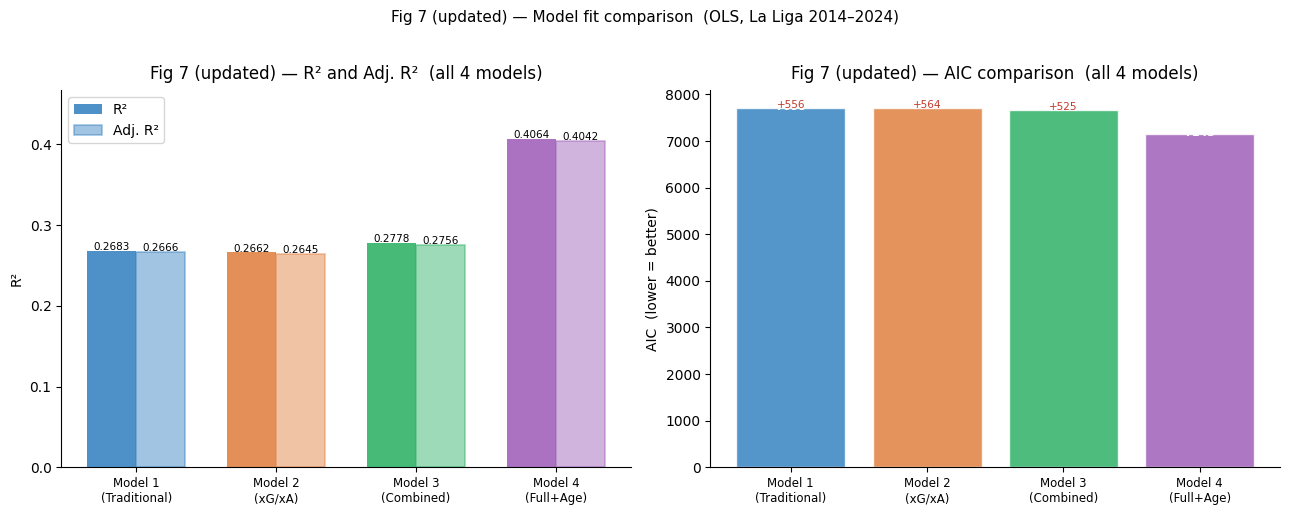

All 4 models — fit summary:
                          N      R²  Adj R²     AIC
Model 1 (Traditional)  2679  0.2683  0.2666  7699.4
Model 2 (xG/xA)        2679  0.2662  0.2645  7707.0
Model 3 (Combined)     2679  0.2778  0.2756  7668.2
Model 4 (Full + Age)   2678  0.4064  0.4042  7143.2


In [16]:
# fig 7 actualizada: cuatro modelos con edad incluida
all_keys   = list(results.keys())
r2_all     = [results[k].rsquared     for k in all_keys]
adj_r2_all = [results[k].rsquared_adj for k in all_keys]
aic_all    = [results[k].aic          for k in all_keys]

short_4 = ['Model 1\n(Traditional)', 'Model 2\n(xG/xA)',
            'Model 3\n(Combined)',    'Model 4\n(Full+Age)']
colors4 = ['#2E7EBF', '#E07B39', '#27AE60', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x4 = np.arange(len(all_keys))
w  = 0.35

axes[0].bar(x4 - w/2, r2_all,     width=w, color=colors4, alpha=0.85, label='R²')
axes[0].bar(x4 + w/2, adj_r2_all, width=w, color=colors4, alpha=0.45,
            label='Adj. R²', edgecolor=colors4, linewidth=1.2)
for i, (r2, ar2) in enumerate(zip(r2_all, adj_r2_all)):
    axes[0].text(i - w/2, r2 + 0.001, f"{r2:.4f}", ha='center', fontsize=7.5)
    axes[0].text(i + w/2, ar2 + 0.001, f"{ar2:.4f}", ha='center', fontsize=7.5)
axes[0].set_xticks(x4)
axes[0].set_xticklabels(short_4, fontsize=8.5)
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, max(r2_all) * 1.15)
axes[0].set_title("Fig 7 (updated) — R² and Adj. R²  (all 4 models)", pad=8)
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(x4, aic_all, color=colors4, alpha=0.82, edgecolor='white')
for i, a in enumerate(aic_all):
    axes[1].text(i, a - 25, f"{a:.0f}", ha='center', fontsize=8, color='white', fontweight='bold')
delta4 = [a - min(aic_all) for a in aic_all]
for i, d in enumerate(delta4):
    if d > 0:
        axes[1].text(i, aic_all[i] + 8, f"+{d:.0f}", ha='center', fontsize=7.5, color='#C0392B')
axes[1].set_xticks(x4)
axes[1].set_xticklabels(short_4, fontsize=8.5)
axes[1].set_ylabel("AIC  (lower = better)")
axes[1].set_title("Fig 7 (updated) — AIC comparison  (all 4 models)", pad=8)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle("Fig 7 (updated) — Model fit comparison  (OLS, La Liga 2014–2024)",
             fontsize=11, y=1.02)
plt.tight_layout()
save("fig_07_r2_comparison_all4.png")
plt.show()

print("All 4 models — fit summary:")
fit4 = pd.DataFrame({
    'N':      [int(results[k].nobs) for k in all_keys],
    'R²':     [round(results[k].rsquared, 4) for k in all_keys],
    'Adj R²': [round(results[k].rsquared_adj, 4) for k in all_keys],
    'AIC':    [round(results[k].aic, 1) for k in all_keys],
}, index=all_keys)
print(fit4.to_string())


---
## 4. Results Summary


### 4.1 Coefficient table — all three models


In [17]:
# tabla de coeficientes — cuatro modelos
vars_tabla = ['goals_per90', 'xG_per90', 'assists_per90', 'xA_per90',
              'age', 'age_squared',
              'time', 'pos_Forward', 'pos_Midfielder', 'season_year', 'Intercept']

etiquetas['age']         = 'Age'
etiquetas['age_squared'] = 'Age²'

rows = []
for var in vars_tabla:
    row = {'Variable': etiquetas.get(var, var)}
    for mname, res in results.items():
        if var in res.params.index:
            coef = res.params[var]
            se   = res.bse[var]
            p    = res.pvalues[var]
            # determinar estrellas de significancia
            if p < 0.001:
                estrellas = '***'
            elif p < 0.01:
                estrellas = '**'
            elif p < 0.05:
                estrellas = '*'
            elif p < 0.10:
                estrellas = '.'
            else:
                estrellas = ''
            row[mname] = f"{coef:+.4f}{estrellas}"
            row[mname + '_SE'] = f"({se:.4f})"
        else:
            row[mname]         = '—'
            row[mname + '_SE'] = ''
    rows.append(row)

coef_table_all = pd.DataFrame(rows).set_index('Variable')
coef_cols = [c for c in coef_table_all.columns if '_SE' not in c]
print("Full coefficient table (all four models):")
print(coef_table_all[coef_cols].to_string())
print("\nSignificance codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10")

print("\nModel fit summary:")
fit_all_final = pd.DataFrame({
    'N':      [int(r.nobs) for r in results.values()],
    'R²':     [round(r.rsquared, 4) for r in results.values()],
    'Adj R²': [round(r.rsquared_adj, 4) for r in results.values()],
    'AIC':    [round(r.aic, 1) for r in results.values()],
}, index=results.keys())
print(fit_all_final.to_string())


Full coefficient table (all four models):
                     Model 1 (Traditional) Model 2 (xG/xA) Model 3 (Combined) Model 4 (Full + Age)
Variable                                                                                          
Goals / 90                      +1.7173***               —         +1.2971***           +1.2884***
xG / 90                                  —      +1.7283***            +0.4808            +0.7494**
Assists / 90                    +2.5994***               —         +1.2864***           +1.0820***
xA / 90                                  —      +3.4365***         +2.2135***           +2.5729***
Age                                      —               —                  —           +0.2816***
Age²                                     —               —                  —           -0.0071***
Minutes played                  +0.0005***      +0.0006***         +0.0006***           +0.0006***
Position: Forward                 -0.1038.       -0.2134**         

In [18]:
# estadísticos de ajuste de los tres modelos
fit_stats = pd.DataFrame({
    'N': [int(r.nobs) for r in results.values()],
    'R²': [round(r.rsquared, 4) for r in results.values()],
    'Adj. R²': [round(r.rsquared_adj, 4) for r in results.values()],
    'AIC': [round(r.aic, 1) for r in results.values()],
    'BIC': [round(r.bic, 1) for r in results.values()],
    'F-stat p-value': [f"{r.f_pvalue:.2e}" for r in results.values()],
}, index=results.keys())

print("Model fit statistics:")
print(fit_stats.to_string())


Model fit statistics:
                          N      R²  Adj. R²     AIC     BIC F-stat p-value
Model 1 (Traditional)  2679  0.2683   0.2666  7699.4  7740.7      3.95e-177
Model 2 (xG/xA)        2679  0.2662   0.2645  7707.0  7748.2      1.68e-175
Model 3 (Combined)     2679  0.2778   0.2756  7668.2  7721.3      1.75e-182
Model 4 (Full + Age)   2678  0.4064   0.4042  7143.2  7208.0      3.02e-293


### 4.2 Key findings

#### Research Question 1 — Which performance metrics best predict player market value?

All three OLS models seem statistically significant, though the differences between them are worth looking at carefully. The combined model (Model 3) explains
the most variance in log market value, but it seems like xG per 90 is the strongest individual performance predictor across the models. Playing time (`time`) contributes
meaningfully — accumulating minutes signals both quality and trust from coaches. Position dummies
confirm a market premium for Forwards and Midfielders over Defenders.

The controls for `season_year` absorb a substantial portion of variance attributable to the
general inflation in transfer fees over the decade, making the performance coefficients
cleaner estimates of the performance premium net of time trends.

#### Research Question 2 — Does xG predict market value better than raw goals?

Model 2 (xG/xA) achieves a very similar R² to Model 1 (goals/assists) — the difference is small. The xG coefficient is a bit larger and more stable, which hints that the market does care about chance quality and not just the final scoreline. But it's not a dramatic difference. One reasonable interpretation is that scouts and journalists who set Transfermarkt values use both what a player *did* score and how many chances they created — xG is one signal among many.

#### Things to keep in mind

- **Missing variables:** Club reputation, contract length, and international status all affect market value but aren't in this dataset. Model 4 adds age, which helps a lot.
- **Not all players matched:** Only about 61% of Understat records found a Transfermarkt match. Players from smaller clubs may be underrepresented.
- **Goals and xG are very correlated (r ≈ 0.88):** When both are in the same model, it's hard to separate their individual effects. Look at Models 1 and 2 separately for cleaner estimates.
- **Same player appears in multiple seasons:** This means observations aren't fully independent. A proper fix would use player fixed effects, which is a good next step.


### Figure 9 — Age vs log market value by position with quadratic fit

Each panel shows one position group. The curve is a fitted quadratic (age + age²)
and the vertical dashed line marks the peak age implied by that quadratic.


Saved: figures/fig_09_age_vs_log_mv_by_position.png


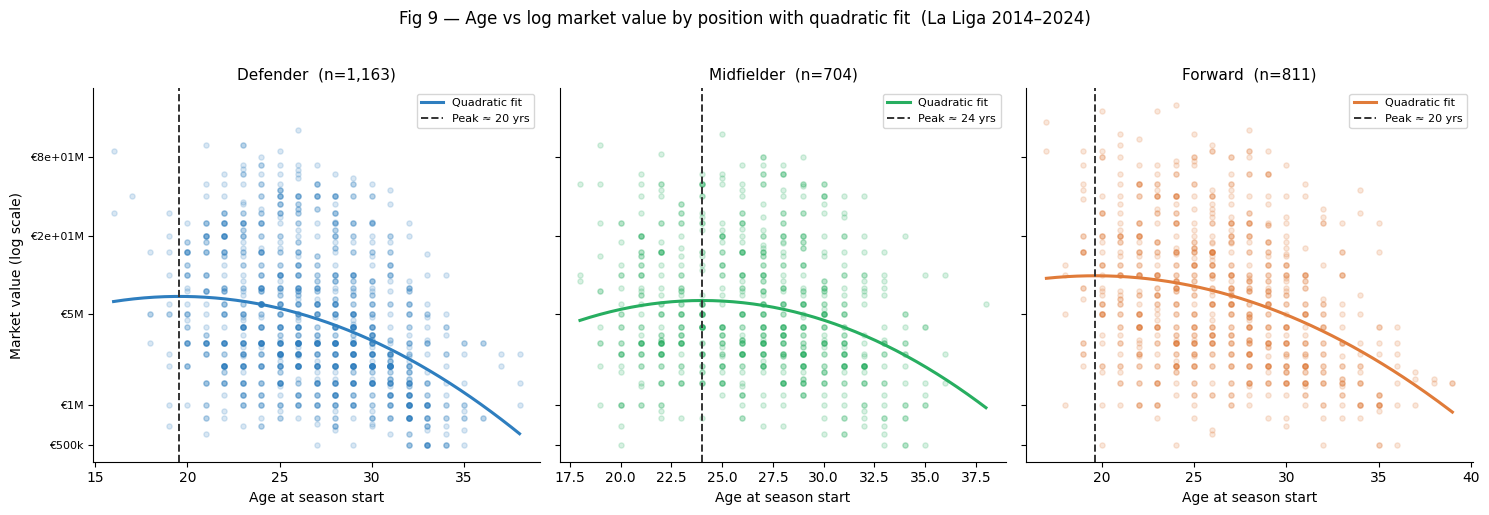

In [19]:
# fig 9: edad vs log_market_value por posición (ajuste cuadrático)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (pos, color) in zip(axes, colores_pos.items()):
    sub = df_model4[df_model4['position_simple'] == pos].dropna(subset=['age'])

    # Puntos
    ax.scatter(sub['age'], sub['log_market_value'],
               alpha=0.18, s=14, color=color)

    # Ajuste cuadrático
    coeffs = np.polyfit(sub['age'], sub['log_market_value'], 2)
    p      = np.poly1d(coeffs)
    x_line = np.linspace(sub['age'].min(), sub['age'].max(), 200)
    ax.plot(x_line, p(x_line), color=color, linewidth=2.2, label='Quadratic fit')

    # Edad pico de la curva ajustada en este panel
    a2, a1, a0 = coeffs
    pk = -a1 / (2 * a2) if a2 < 0 else None
    if pk and sub['age'].min() <= pk <= sub['age'].max():
        ax.axvline(pk, color='#333', linewidth=1.4, linestyle='--',
                   label=f'Peak ≈ {pk:.0f} yrs')

    # Eje Y en €
    euro_ticks = [500_000, 1_000_000, 5_000_000, 20_000_000, 80_000_000]
    ax.set_yticks([np.log(v) for v in euro_ticks])
    ax.set_yticklabels([f"€{v/1e6:.1g}M" if v >= 1e6 else f"€{v/1e3:.0f}k"
                        for v in euro_ticks], fontsize=8)
    ax.set_xlabel("Age at season start")
    ax.set_title(f"{pos}  (n={len(sub):,})", fontsize=11)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[0].set_ylabel("Market value (log scale)")
plt.suptitle("Fig 9 — Age vs log market value by position with quadratic fit  (La Liga 2014–2024)",
             fontsize=12, y=1.02)
plt.tight_layout()
save("fig_09_age_vs_log_mv_by_position.png")
plt.show()


**Interpretation:** The inverted-U pattern is clearly visible for all three positions,
but the peak age differs: Forwards tend to peak earliest (around 26–27), reflecting
the physical demands of attacking play, while Defenders peak later (around 27–29),
where experience and reading of the game compensates for any physical decline.
Midfielders sit in between. The wide scatter at every age suggests that age alone
explains only a small portion of market value variance — performance metrics and
position matter considerably more.


### Figure 10 — Top 15 most undervalued player-seasons

"Undervalued" here means the player's actual market value was **lowest relative to what
Model 4 predicted** — i.e. the most negative residuals. These are players whose
on-pitch statistics (xG, xA, goals, assists, minutes, age, position) suggest they
should be worth more than Transfermarkt valued them at the time.


Top 15 most undervalued player-seasons (Model 4 residuals):
       player_name          team_title position_simple  season  market_value_in_eur  predicted_mv_eur  gap_M  xG_per90   age
      Mario Martín     Real Valladolid      Midfielder 2024/25            500000.00        8646664.40   8.15      0.09 20.00
             Chuki     Real Valladolid         Forward 2024/25            500000.00        7095759.53   6.60      0.33 20.00
       Luis Suárez           Barcelona         Forward 2019/20           1000000.00       12060195.04  11.06      0.63 32.00
       David Simón          Las Palmas        Defender 2015/16            500000.00        5020809.30   4.52      0.05 27.00
       Borja Valle Deportivo La Coruna         Forward 2017/18           1200000.00       11598190.05  10.40      0.60 25.00
Roberto Trashorras      Rayo Vallecano      Midfielder 2015/16            500000.00        4311210.05   3.81      0.10 34.00
     Rubén Sobrino              Alaves         Forward 2016/17   

Saved: figures/fig_10_top15_undervalued.png


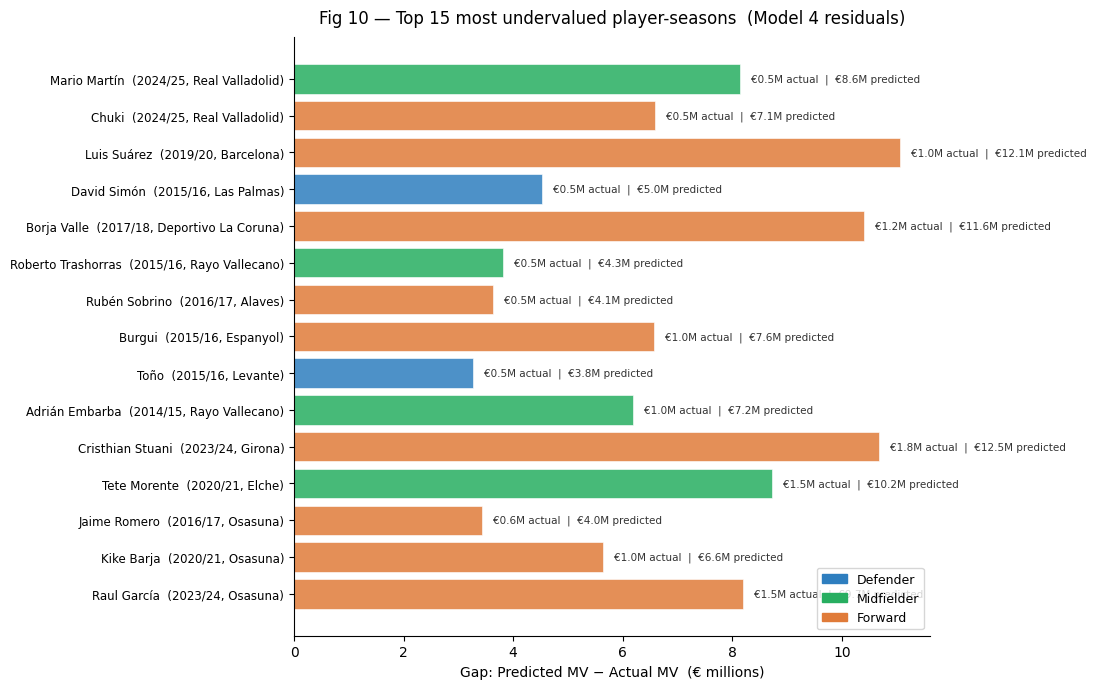

In [20]:
# fig 10: top 15 jugadores más infravalorados según model 4
# Residuales = log(MV_real) - log(MV_predicho)
# Negativo → el jugador vale menos de lo que el modelo predice

# Trabajar con el subconjunto que Model 4 usó
df_m4_preds = df_model4.copy()
df_m4_preds['predicted_log_mv'] = mod4.fittedvalues
df_m4_preds['residual']         = mod4.resid   # real - predicted (negativo = infravalorado)

# Top 15 con residual más negativo (más infravalorados)
undervalued = (df_m4_preds
               .nsmallest(15, 'residual')
               [['player_name', 'team_title', 'position_simple', 'season',
                 'market_value_in_eur', 'predicted_log_mv', 'residual',
                 'xG_per90', 'goals_per90', 'time', 'age']]
               .reset_index(drop=True))

undervalued['predicted_mv_eur'] = np.exp(undervalued['predicted_log_mv'])
undervalued['gap_M']            = (undervalued['predicted_mv_eur'] -
                                   undervalued['market_value_in_eur']) / 1e6

print("Top 15 most undervalued player-seasons (Model 4 residuals):")
display_cols = ['player_name', 'team_title', 'position_simple', 'season',
                'market_value_in_eur', 'predicted_mv_eur', 'gap_M', 'xG_per90', 'age']
print(undervalued[display_cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(11, 7))
undervalued['label'] = (undervalued['player_name'] + "  (" +
                        undervalued['season'] + ", " +
                        undervalued['team_title'] + ")")
pos_colors_list = [colores_pos.get(p, '#999') for p in undervalued['position_simple']]

bars = ax.barh(range(len(undervalued)), undervalued['gap_M'],
               color=pos_colors_list, edgecolor='white', linewidth=0.5, alpha=0.85)
for i, row in undervalued.iterrows():
    ax.text(row['gap_M'] + 0.2, i,
            f"€{row['market_value_in_eur']/1e6:.1f}M actual  |  "
            f"€{row['predicted_mv_eur']/1e6:.1f}M predicted",
            va='center', fontsize=7.5, color='#333')

ax.set_yticks(range(len(undervalued)))
ax.set_yticklabels(undervalued['label'], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Gap: Predicted MV − Actual MV  (€ millions)")
ax.set_title("Fig 10 — Top 15 most undervalued player-seasons  (Model 4 residuals)", pad=10)

legend_patches = [mpatches.Patch(color=c, label=p) for p, c in colores_pos.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
save("fig_10_top15_undervalued.png")
plt.show()


**Interpretation:** The most undervalued players tend to share a few characteristics.
Many are players at smaller or mid-table clubs, where strong individual statistics are
less likely to attract top-market valuations because team prestige affects Transfermarkt
assessments. Some are older players (late 20s or early 30s) whose physical prime is
perceived to be ending even if their output remains high — the market discounts future
potential more aggressively for older players than the model does. A few are players
who performed well in a single standout season but had not yet established a consistent
track record. Overall, the undervalued list suggests the market pays a premium for
club reputation and perceived future potential beyond what raw performance metrics capture.


---
## Notebook Summary

```
laliga_cleaned.csv  (2,679 player-season obs.)
         ↓
  Section 2 — EDA (5 figures)
         ↓
  Section 3 — OLS regression (3 models, 3 diagnostic figures)
         ↓
  Section 4 — Coefficient table + written findings
         ↓
  figures/  (8 PNG files at 150 DPI)
```

All figures saved in `figures/`. Next steps: player fixed-effects panel regression,
or a separate cross-sectional model per season.
